In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, List

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
vector1 = np.array([2, 3, 4, 6, 8, 7, 6, 5, 4, 3, 2])
vector2 = np.array([2, 4, 6, 7, 7, 6, 5, 5, 4, 3, 2, 2, 1])

print(f"Vector 1 shape: {vector1.shape}")
print(f"Vector 2 shape: {vector2.shape}")
print(f"\nVector 1: {vector1}")
print(f"Vector 2: {vector2}")

Vector 1 shape: (11,)
Vector 2 shape: (13,)

Vector 1: [2 3 4 6 8 7 6 5 4 3 2]
Vector 2: [2 4 6 7 7 6 5 5 4 3 2 2 1]


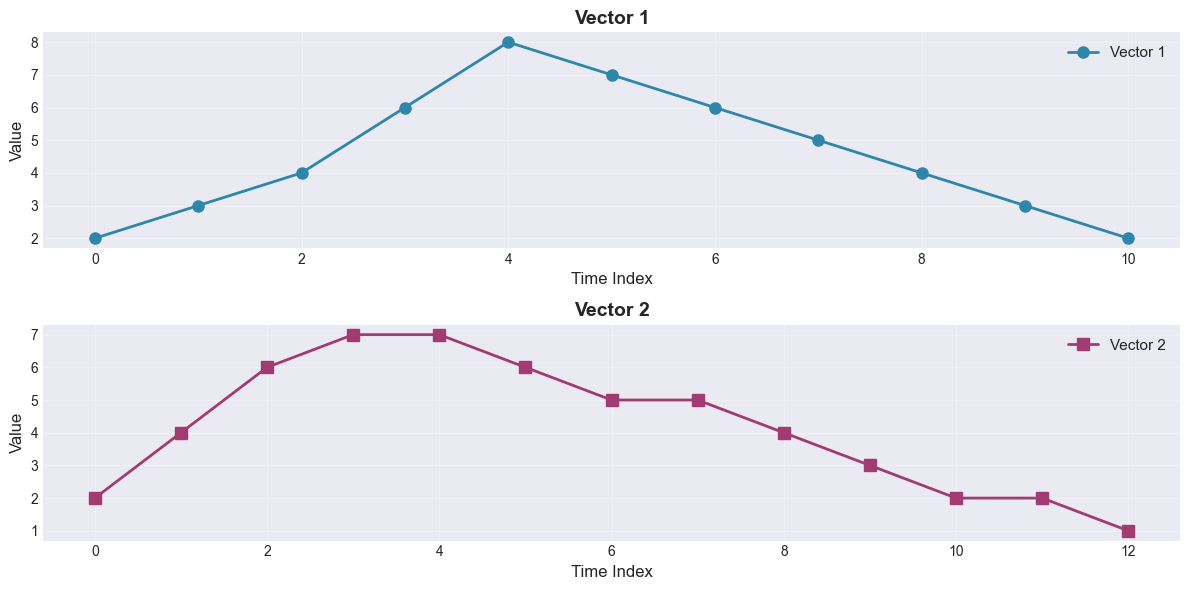

In [3]:
# Task 1: Plot both vectors to visualize their patterns
def plot_vectors(vec1: np.ndarray, vec2: np.ndarray) -> None:
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
    
    # Plot Vector 1
    ax1.plot(vec1, marker='o', linestyle='-', linewidth=2, 
             markersize=8, color='#2E86AB', label='Vector 1')
    ax1.set_title('Vector 1', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Time Index', fontsize=12)
    ax1.set_ylabel('Value', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11)
    
    # Plot Vector 2
    ax2.plot(vec2, marker='s', linestyle='-', linewidth=2, 
             markersize=8, color='#A23B72', label='Vector 2')
    ax2.set_title('Vector 2', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Time Index', fontsize=12)
    ax2.set_ylabel('Value', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()

# Visualize the vectors
plot_vectors(vector1, vector2)

In [4]:
# Task 2: Implement Dynamic Time Warping algorithm
def compute_dtw(vec1: np.ndarray, vec2: np.ndarray) -> Tuple[np.ndarray, float]:

    n, m = len(vec1), len(vec2)
    
    # Initialize cost matrix with infinity
    cost_matrix = np.full((n + 1, m + 1), np.inf)
    cost_matrix[0, 0] = 0
    
    # Compute accumulated cost matrix
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            # Euclidean distance between current points
            cost = abs(vec1[i-1] - vec2[j-1])
            
            # Take minimum of three possible paths
            cost_matrix[i, j] = cost + min(
                cost_matrix[i-1, j],      # Insertion
                cost_matrix[i, j-1],      # Deletion
                cost_matrix[i-1, j-1]     # Match
            )
    
    # DTW distance is the value at bottom-right corner
    dtw_distance = cost_matrix[n, m]
    
    return cost_matrix[1:, 1:], dtw_distance

# Compute DTW
cost_matrix, dtw_distance = compute_dtw(vector1, vector2)

print(f"Cost Matrix Shape: {cost_matrix.shape}")
print(f"DTW Distance: {dtw_distance:.4f}")

Cost Matrix Shape: (11, 13)
DTW Distance: 3.0000
